In [1]:
# Python Standard Library
import sys
from os import mkdir
from os.path import join
from os.path import isdir
from shutil import rmtree

# Community Modules
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy import stats

# My Modules
sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du
from matplotlib import pyplot as plt
import plotly.express as px
import plotly

rng = np.random.default_rng(1415)

2026-03-25 13:19:50.588071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 13:19:50.607804: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 13:19:50.613847: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 13:19:50.629471: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 13:19:52.460541: W tensorflow/compiler/tf2

In [2]:
wvl, df_meta, spectra, spectra_signal, spectra_noise = du.load_dataset()

num_wvl = wvl.size
num_spectra = spectra.shape[0]

In [9]:
SiII = 6355
mask = wvl >= SiII - 100
mask &= wvl <= SiII
wvl[mask].shape

(12,)

In [12]:
df_meta["N (SNR)"]

0       0.005451
1       0.003175
2       0.003304
3       0.005674
4       0.005125
          ...   
3569    0.003740
3570    0.010965
3571    0.004338
3572    0.004083
3573    0.005497
Name: N (SNR), Length: 3574, dtype: float64

In [3]:
new_SNR = 100
new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
new_spectra = spectra_signal + new_noise

In [4]:
subtypes_ID = df_meta["SN Subtype ID"].unique()
subtypes_ID_to_str = dict(
    df_meta.groupby(by="SN Subtype ID")["SN Subtype"].apply(
        lambda x: x.to_numpy()[0]))

In [5]:
for i in tqdm(range(num_spectra)):
    i_row_series = df_meta.loc[i]
    i_spectra = spectra[i]
    i_spectra_signal = spectra_signal[i]
    i_spectra_noise = spectra_noise[i]
    i_new_noise = new_noise[i]

    # i_specsnr = ms.SpectrumSNR(
    #     i_row_series["SN Name"],
    #     i_row_series["SN Subtype"],
    #     i_row_series["Spectrum Phase"],
    #     wvl,
    #     i_spectra)
    # i_specsnr.execute_algorithm(i_row_series)

    i_specsnr_new_noise = ms.SpectrumSNR(
        i_row_series["SN Name"],
        i_row_series["SN Subtype"],
        i_row_series["Spectrum Phase"],
        wvl,
        i_spectra)
    i_specsnr_new_noise.execute_algorithm(i_row_series, new_noise=i_new_noise)
    
    df_meta.loc[i, "new_measured_SNR"] = i_specsnr_new_noise.SNR
    df_meta.loc[i, "new_measured_N"] = i_specsnr_new_noise.N

100%|██████████| 3574/3574 [04:04<00:00, 14.61it/s]


In [6]:
df_meta

,SN Name,Spectrum Phase,Spectrum Cardinality,SN Subtype,SN Maintype,SN Subtype ID,SN Maintype ID,SNR,S (SNR),N (SNR),...,searchRed,minima_i,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed,useBlu,useRed,new_measured_SNR,new_measured_N
0,sn1981b,-1.5,1,Ia-norm,Ia,0,0,1871.524905,10.201020,0.005451,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,115.420670,0.088381
1,sn1981b,15.4,1,Ia-norm,Ia,0,0,2098.887305,6.663471,0.003175,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,107.451399,0.062014
2,sn1981b,18.3,1,Ia-norm,Ia,0,0,2239.138885,7.397255,0.003304,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,103.550416,0.071436
3,sn1981b,22.3,1,Ia-norm,Ia,0,0,556.796633,3.159352,0.005674,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,107.371923,0.029424
4,sn1989b,-7.2,1,Ia-norm,Ia,0,0,1568.676779,8.039676,0.005125,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,99.832981,0.080531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3569,sn2006bp,17.2,1,IIP,II,9,3,1909.429755,7.142203,0.003740,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,103.827577,0.068789
3570,sn2006bp,20.1,1,IIP,II,9,3,639.508576,7.011980,0.010965,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,96.165326,0.072916
3571,sn2006bp,25.2,1,IIP,II,9,3,2430.950291,10.546622,0.004338,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,120.515726,0.087512
3572,sn2006bp,34.1,1,IIP,II,9,3,3897.900603,15.915556,0.004083,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,105.375962,0.151036


In [7]:
fig = px.scatter(
    data_frame=df_meta,
    x="SNR",
    y="new_measured_SNR",
    color="SN Subtype",
    hover_name="SN Name",
    hover_data=["Spectrum Phase", "N (SNR)", "new_measured_N"],
)
plotly.offline.plot(fig, filename=f"SNR_vs_newMeasuredSNR_atSNR{new_SNR}.html");

)07=                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [8]:
fig = px.scatter(
    data_frame=df_meta,
    x="S (SNR)",
    y="new_measured_SNR",
    color="SN Subtype",
    hover_name="SN Name",
    hover_data=["Spectrum Phase", "SNR", "N (SNR)", "new_measured_N"],
)
plotly.offline.plot(fig, filename=f"S_vs_newMeasuredSNR_atSNR{new_SNR}.html")

)07=                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

'S_vs_newMeasuredSNR_atSNR100.html'

(array([  1.,  15.,  58., 180., 315., 547., 563., 534., 433., 342., 195.,
        149.,  99.,  53.,  31.,  27.,  12.,   7.,   4.,   2.,   3.,   1.,
          1.,   1.,   1.]),
 array([ 59.86315003,  66.40319351,  72.943237  ,  79.48328049,
         86.02332397,  92.56336746,  99.10341094, 105.64345443,
        112.18349791, 118.7235414 , 125.26358489, 131.80362837,
        138.34367186, 144.88371534, 151.42375883, 157.96380232,
        164.5038458 , 171.04388929, 177.58393277, 184.12397626,
        190.66401974, 197.20406323, 203.74410672, 210.2841502 ,
        216.82419369, 223.36423717]),
 <BarContainer object of 25 artists>)

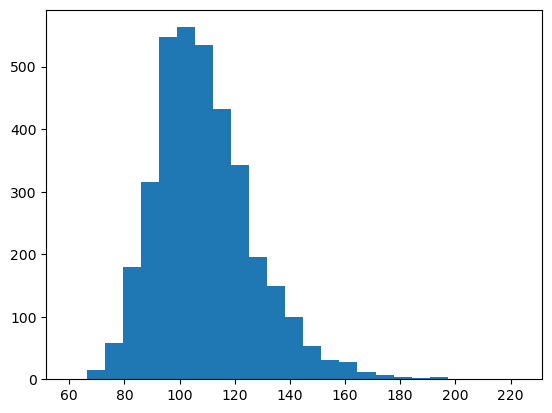

In [11]:
plt.hist(df_meta["new_measured_SNR"], bins=25)